In [116]:
import torch
import time 

import matplotlib.pyplot as plt
import numpy as np

from oracle.architectures import GRU_MD_Improved, GRU_MD_MM_Improved, GRU_Improved, ConvNeXt
from oracle.taxonomies import BTS_Taxonomy, ORACLE_Taxonomy

In [117]:
import os
import psutil
import torch


os.environ["OMP_NUM_THREADS"] = "10"
os.environ["MKL_NUM_THREADS"] = "10"
os.environ["VECLIB_MAXIMUM_THREADS"] = "10"  # especially relevant on macOS

torch.set_num_threads(10)

print(torch.get_num_threads())
print(torch.get_num_interop_threads())

10
1


In [118]:
taxonomy = BTS_Taxonomy()
elasticc_taxonomy = ORACLE_Taxonomy()

In [119]:


bts_oracle2 = GRU_MD_Improved(taxonomy)
bts_oracle2_omni = GRU_MD_MM_Improved(taxonomy, image_model_dir=None, lc_md_model_dir=None)
bts_oracle2_lite = GRU_Improved(taxonomy)

elasticc_oracle2 = GRU_MD_Improved(elasticc_taxonomy, static_feature_dim=18)
elasticc_oracle2_lite = GRU_Improved(elasticc_taxonomy)

image_backbone = ConvNeXt(taxonomy)

bts_oracle2_lite.eval()
bts_oracle2.eval()
bts_oracle2_omni.eval()
elasticc_oracle2.eval()
elasticc_oracle2_lite.eval()
image_backbone.eval()



ConvNeXt(
  (convnext): ConvNeXt(
    (stem): Sequential(
      (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((64,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): ConvNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvNeXtBlock(
            (conv_dw): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=64)
            (norm): LayerNorm2d((64,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1))
              (act): GELU()
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1))
              (drop2): Dropout(p=0.0, inplace=False)
            )
            (shortcut): Identity()
            (drop_path): Identity()
          )
          (1): ConvNeXtBlock(
            (conv_dw): Conv2

In [120]:
F1_scores_max = {
    "Oracle-2 Lite (BTS)": 0.59,
    "Oracle-2 (BTS)": 0.70,
    "Oracle-2 Omni (BTS)": 0.73,
    "Oracle-2 Lite (ELAsTiCC)": 0.83,
    "Oracle-2 (ELAsTiCC)": 0.88,
}

F1_scores_min = {
    "Oracle-2 Lite (BTS)": 0.19,
    "Oracle-2 (BTS)": 0.49,
    "Oracle-2 Omni (BTS)": 0.59,
    "Oracle-2 Lite (ELAsTiCC)": 0.54,
    "Oracle-2 (ELAsTiCC)": 0.67,
}

models = {
    "Oracle-2 Lite (BTS)": bts_oracle2_lite,
    "Oracle-2 (BTS)": bts_oracle2,
    "Oracle-2 Omni (BTS)": bts_oracle2_omni,
    "Image Backbone (BTS)": image_backbone,
    "Oracle-2 Lite (ELAsTiCC)": elasticc_oracle2_lite,
    "Oracle-2 (ELAsTiCC)": elasticc_oracle2,
}

colors = {
    'Oracle-2 Lite (BTS)': '#994882',
    'Oracle-2 (BTS)': '#008080',
    'Oracle-2 Omni (BTS)': '#FF6645',
    'Oracle-2 Lite (ELAsTiCC)': "crimson",
    'Oracle-2 (ELAsTiCC)': "steelblue",
}

markers = {
    'Oracle-2 Lite (BTS)': 's',
    'Oracle-2 (BTS)': 'D',
    'Oracle-2 Omni (BTS)': 'o',
    'Oracle-2 Lite (ELAsTiCC)': "X",
    'Oracle-2 (ELAsTiCC)': "*",
}

mean_times = {}
std_times = {}
mean_throughput = {}
std_throughput = {}
parameter_counts = {}

for m in models:
    parameter_counts[m] = sum(p.numel() for p in models[m].parameters())

In [121]:
# Benchmarking the throughput of the two models
num_iterations = 100
batch_size = 1


for m in models:

    if 'BTS' in m:
        static_dim = 30
        sequence_length = 30
    else:
        static_dim = 18
        sequence_length = 110

    batch = {
        "ts": torch.randn(batch_size, sequence_length, 5, dtype=torch.float32),  # (batch_size, seq_len, num_features)
        "static": torch.randn(batch_size, static_dim, dtype=torch.float32),
        "length": torch.from_numpy(np.array([sequence_length] * batch_size)),  # (batch_size,)
        "postage_stamp": torch.randn(batch_size, 3, 63, 63, dtype=torch.float32)  # (batch_size, num_channels, height, width)
    }


    model = models[m].eval()

    with torch.inference_mode():
        for _ in range(10):
            model(batch)

        times = []
        throughput = []
        for _ in range(num_iterations):
            start_time = time.time()
            model(batch)
            end_time = time.time()
            times.append((end_time - start_time))
            throughput.append(1 / (end_time - start_time))
        mean_times[m] = np.mean(times)
        std_times[m] = np.std(times)
        mean_throughput[m] = np.mean(throughput)
        std_throughput[m] = np.std(throughput)
    

In [122]:
mean_times

{'Oracle-2 Lite (BTS)': np.float64(0.0023337984085083007),
 'Oracle-2 (BTS)': np.float64(0.002429218292236328),
 'Oracle-2 Omni (BTS)': np.float64(0.19679851055145264),
 'Image Backbone (BTS)': np.float64(0.19255327463150024),
 'Oracle-2 Lite (ELAsTiCC)': np.float64(0.007986125946044921),
 'Oracle-2 (ELAsTiCC)': np.float64(0.008455109596252442)}

In [123]:
std_times

{'Oracle-2 Lite (BTS)': np.float64(0.00019861033317259026),
 'Oracle-2 (BTS)': np.float64(0.00036551584224254146),
 'Oracle-2 Omni (BTS)': np.float64(0.024924355639318337),
 'Image Backbone (BTS)': np.float64(0.03439352577994651),
 'Oracle-2 Lite (ELAsTiCC)': np.float64(0.0010535641962169538),
 'Oracle-2 (ELAsTiCC)': np.float64(0.0038683003362431486)}

In [124]:
mean_throughput

{'Oracle-2 Lite (BTS)': np.float64(431.2158410131431),
 'Oracle-2 (BTS)': np.float64(417.5697610644134),
 'Oracle-2 Omni (BTS)': np.float64(5.159398892737589),
 'Image Backbone (BTS)': np.float64(5.31524489866106),
 'Oracle-2 Lite (ELAsTiCC)': np.float64(126.66169245125313),
 'Oracle-2 (ELAsTiCC)': np.float64(124.06182233798233)}

In [125]:
std_throughput

{'Oracle-2 Lite (BTS)': np.float64(32.34075097009558),
 'Oracle-2 (BTS)': np.float64(41.572309089024564),
 'Oracle-2 Omni (BTS)': np.float64(0.6273213547320661),
 'Image Backbone (BTS)': np.float64(0.7242712925806241),
 'Oracle-2 Lite (ELAsTiCC)': np.float64(11.517523920174014),
 'Oracle-2 (ELAsTiCC)': np.float64(14.789548708891807)}

In [126]:
# make a table of the results
import pandas as pd

results_df = pd.DataFrame({
    'Model': list(models.keys()),
    'Mean Inference Time (s)': [mean_times[m] for m in models],
    'Inference Time Std (s)': [std_times[m] for m in models],
    # 'F1 Score Min': [F1_scores_min[m] for m in models],
    # 'F1 Score Max': [F1_scores_max[m] for m in models],
    'Num Parameters': [parameter_counts[m] for m in models]
})

# make the formatted table with the mean and std in the same column
results_df['Inference Time (s)'] = results_df.apply(lambda row: f"{row['Mean Inference Time (s)']:.4f} ± {row['Inference Time Std (s)']:.3f}", axis=1)
results_df.drop(columns=['Mean Inference Time (s)', 'Inference Time Std (s)'], inplace=True)


results_df

,Model,Num Parameters,Inference Time (s)
0,Oracle-2 Lite (BTS),502426,0.0023 ± 0.000
1,Oracle-2 (BTS),529242,0.0024 ± 0.000
2,Oracle-2 Omni (BTS),9211598,0.1968 ± 0.025
3,Image Backbone (BTS),8681658,0.1926 ± 0.034
4,Oracle-2 Lite (ELAsTiCC),502698,0.0080 ± 0.001
5,Oracle-2 (ELAsTiCC),528746,0.0085 ± 0.004


In [127]:
print(results_df.to_latex(index=False))

\begin{tabular}{lrl}
\toprule
Model & Num Parameters & Inference Time (s) \\
\midrule
Oracle-2 Lite (BTS) & 502426 & 0.0023 ± 0.000 \\
Oracle-2 (BTS) & 529242 & 0.0024 ± 0.000 \\
Oracle-2 Omni (BTS) & 9211598 & 0.1968 ± 0.025 \\
Image Backbone (BTS) & 8681658 & 0.1926 ± 0.034 \\
Oracle-2 Lite (ELAsTiCC) & 502698 & 0.0080 ± 0.001 \\
Oracle-2 (ELAsTiCC) & 528746 & 0.0085 ± 0.004 \\
\bottomrule
\end{tabular}



/var/folders/t6/gdw9ytlx48nd402t7_62k3r00000gn/T/ipykernel_68635/953080877.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, loc='lower right')


KeyError: 'Image Backbone (BTS)'

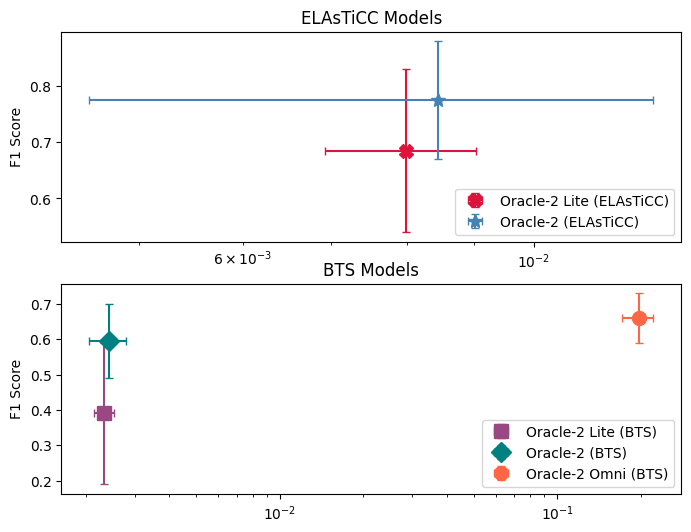

In [128]:
# Create figure with subplots for ELAsTiCC and BTS models
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Configure subplots
for ax, title in zip([ax1, ax2], ['ELAsTiCC Models', 'BTS Models']):
    ax.set_title(title)
    ax.set_ylabel('F1 Score')
    ax.set_xscale('log')
    ax.legend(fontsize=10, loc='lower right')

# Separate models by dataset
elasticc_models = [m for m in models if 'ELAsTiCC' in m]
bts_models = [m for m in models if 'BTS' in m]

# Plot each model group
for ax, model_list in zip([ax1, ax2], [elasticc_models, bts_models]):
    for m in model_list:
        mean_score = (F1_scores_max[m] + F1_scores_min[m]) / 2
        score_scale = (F1_scores_max[m] - F1_scores_min[m]) / 2
        
        ax.errorbar(
            mean_times[m], mean_score,
            xerr=std_times[m], yerr=score_scale,
            fmt=markers[m], color=colors[m], label=m,
            capsize=3, markersize=10
        )
        ax.legend(fontsize=10, loc='lower right')

fig.suptitle('Model Performance vs Inference Time', fontsize=14)
plt.tight_layout()
plt.show()